Q3: Risk-Sensitive Robot Navigation Near Hazards

Environment Defined

In [82]:
import numpy as np
GRID_SIZE = 10
GAMMA = 0.9

STEP_REWARD = -1
GOAL_REWARD = 50
FAILURE_REWARD = -200

GOAL = (8, 1)
FAILURE_STATE = "FAILURE"

ACTIONS = ["Up", "Down", "Left", "Right"]

HAZARD_CELLS = {
    (3,0),(3,1),(3,2),(3,3),(3,4),
    (4,0),(4,1),(4,2),(4,3),(4,4),
    (5,0),(5,1),(5,2),(5,3),(5,4),
}



def compute_h(x, y):
    return min(abs(x - hx) + abs(y - hy) for (hx, hy) in HAZARD_CELLS)          #manhattan distance



def slip_probability(h):                        #we can see slip prob depends on the proximity
    
    if h >= 4:
        return 0.05
    elif h == 3:
        return 0.1
    elif h == 2:
        return 0.2
    elif h == 1:
        return 0.3
    else:                          #(inside hazard)
        return 0.7



states = []

for x in range(GRID_SIZE):
    for y in range(GRID_SIZE):
        h = compute_h(x, y)
        states.append((x, y, h))

states.append(FAILURE_STATE)

terminal_states = {FAILURE_STATE}


for state in states:
    if state != FAILURE_STATE:
        if (state[0], state[1]) == GOAL:
            terminal_states.add(state)



def get_transitions(state, action):
    if state in terminal_states:
        return []

    x, y, h = state

    def valid_cell(a, b):
        return 0 <= a < GRID_SIZE and 0 <= b < GRID_SIZE

    p_slip = slip_probability(h)


    if action == "Up":
        nx, ny = x, y+1
        slip_cells = [(x-1,y), (x+1,y)]

    elif action == "Down":
        nx, ny = x, y-1
        slip_cells = [(x-1,y), (x+1,y)]

    elif action == "Left":
        nx, ny = x-1, y
        slip_cells = [(x,y+1), (x,y-1)]

    elif action == "Right":
        nx, ny = x+1, y
        slip_cells = [(x,y+1), (x,y-1)]

    transitions = []


    # Intended Move
    if valid_cell(nx, ny):
        next_h = compute_h(nx, ny)

        if h <= 1:                  # If very close to hazard -> catastrophic risk
            transitions.append(
                (1 - p_slip,
                 (nx, ny, next_h),
                 GOAL_REWARD if (nx, ny) == GOAL else STEP_REWARD)
            )

            transitions.append(
                (p_slip,
                 FAILURE_STATE,
                 FAILURE_REWARD)
            )

            return transitions

        else:
            transitions.append(
                (1 - p_slip,
                 (nx, ny, next_h),
                 GOAL_REWARD if (nx, ny) == GOAL else STEP_REWARD)
            )

    else:
        transitions.append(                     # Hit boundary -> stay in place
            (1 - p_slip,
             (x, y, h),
             STEP_REWARD)
        )


    # Slip Moves (only if not catastrophic zone)
    if h > 1:

        for sx, sy in slip_cells:

            if valid_cell(sx, sy):
                next_h = compute_h(sx, sy)
                reward = GOAL_REWARD if (sx, sy) == GOAL else STEP_REWARD
                transitions.append(
                    (p_slip / 2,
                     (sx, sy, next_h),
                     reward)
                )
            else:
                transitions.append(
                    (p_slip / 2,
                     (x, y, h),
                     STEP_REWARD)
                )

    return transitions


Value Iteration

In [83]:
def run_value_iteration(states, terminal_states,
                        tol=1e-6, max_iters=1000):

    V = {s: 0.0 for s in states}

    iterations = 0

    for k in range(max_iters):

        delta = 0
        V_new = V.copy()

        for s in states:

            if s in terminal_states:
                continue                # V(terminal) = 0

            best_val = -float("inf")

            for a in ACTIONS:

                val = 0.0
                transitions = get_transitions(s, a)

                for p, s_next, r in transitions:
                    val += p * (r + GAMMA * V[s_next])

                best_val = max(best_val, val)

            V_new[s] = best_val
            delta = max(delta, abs(best_val - V[s]))

        V = V_new
        iterations += 1

        if delta < tol:
            break


    # Extracting Optimal Policy
    policy = {}

    for s in states:

        if s in terminal_states:
            policy[s] = None
            continue

        best_action = None
        best_val = -float("inf")

        for a in ACTIONS:

            val = 0.0
            transitions = get_transitions(s, a)

            for p, s_next, r in transitions:
                val += p * (r + GAMMA * V[s_next])

            if val > best_val:
                best_val = val
                best_action = a

        policy[s] = best_action

    return V, policy, iterations



# Run Value Iteration
V, policy, iters = run_value_iteration(states, terminal_states)

print("Value Iteration converged in:", iters, "iterations")


Value Iteration converged in: 44 iterations


Visualising Policies using arrows

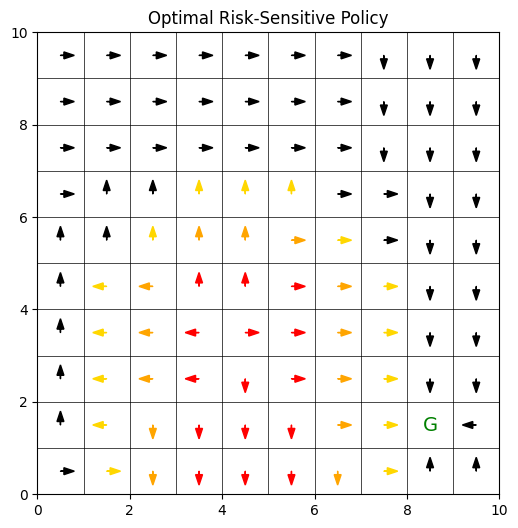

In [84]:
import matplotlib.pyplot as plt

def visualize_policy(policy, title="Optimal Policy"):

    plt.figure(figsize=(6,6))

    for i in range(GRID_SIZE+1):
        plt.plot([0, GRID_SIZE], [i, i], color='black', linewidth=0.5)
        plt.plot([i, i], [0, GRID_SIZE], color='black', linewidth=0.5)


    
    for x in range(GRID_SIZE):                              # Draw Policy
        for y in range(GRID_SIZE):

            h = compute_h(x, y)
            state = (x, y, h)

            if state in terminal_states:
                continue

            if state not in policy:
                continue

            action = policy[state]

            if action is None:
                continue

            # Arrow symbols
            if action == "Up":
                dx, dy = 0, 0.3
            elif action == "Down":
                dx, dy = 0, -0.3
            elif action == "Left":
                dx, dy = -0.3, 0
            elif action == "Right":
                dx, dy = 0.3, 0

            
            if (x, y) in HAZARD_CELLS:              # Color coding by risk proximity
                color = "red"
            elif h == 1:
                color = "orange"
            elif h == 2:
                color = "gold"
            else:
                color = "black"

            plt.arrow(x+0.5, y+0.5,
                      dx, dy,
                      head_width=0.15,
                      length_includes_head=True,
                      color=color)


    gx, gy = GOAL
    plt.text(gx+0.5, gy+0.5, "G",
             ha='center', va='center',
             fontsize=14, color='green')


    plt.xlim(0, GRID_SIZE)
    plt.ylim(0, GRID_SIZE)
    plt.gca().set_aspect('equal')
    plt.title(title)
    plt.show()


visualize_policy(policy, title="Optimal Risk-Sensitive Policy")


Policy Iteration

In [85]:
def run_policy_iteration(states, terminal_states,
                         tol=1e-6,
                         max_policy_eval_iters=1000,
                         max_policy_iters=100):

    V = {s: 0.0 for s in states}


    policy = {}

    for s in states:
        if s in terminal_states:
            policy[s] = None
        else:
            policy[s] = np.random.choice(ACTIONS)

    policy_stable = False
    policy_iterations = 0


    while not policy_stable and policy_iterations < max_policy_iters:

        #Policy Evaluation
        for _ in range(max_policy_eval_iters):

            delta = 0

            for s in states:

                if s in terminal_states:
                    continue

                v_old = V[s]
                a = policy[s]

                val = 0.0
                transitions = get_transitions(s, a)

                for p, s_next, r in transitions:
                    val += p * (r + GAMMA * V[s_next])

                V[s] = val
                delta = max(delta, abs(v_old - val))

            if delta < tol:
                break

        # Policy Improvement
        policy_stable = True

        for s in states:

            if s in terminal_states:
                continue

            old_action = policy[s]

            best_action = None
            best_value = -float("inf")

            for a in ACTIONS:

                val = 0.0
                transitions = get_transitions(s, a)

                for p, s_next, r in transitions:
                    val += p * (r + GAMMA * V[s_next])

                if val > best_value:
                    best_value = val
                    best_action = a

            policy[s] = best_action

            if old_action != best_action:
                policy_stable = False

        policy_iterations += 1

    return V, policy, policy_iterations

V_pi, policy_pi, pi_iters = run_policy_iteration(states, terminal_states)

print("Policy Iteration converged in:", pi_iters, "policy improvement steps")


Policy Iteration converged in: 10 policy improvement steps
